# <h1 style="text-align: center; font-weight: bolder;">LAB 9</h1>
# <h1 style="text-align: center; font-weight: bold;">TRANSFER LEARNING</h1>


**Goal:** Train a lightweight MLP classifier on top of embeddings extracted from a pretrained audio representation model, using the MagnaTagATune (MTAT) multi-label dataset.

**Key requirements and extras covered**
* Colab/CUDA + Mac MPS + CPU fallback
* End-to-end resource + environmental impact tracking
* Efficient embedding extraction + disk cache
* Clear metrics for multi-label tagging: ROC-AUC and PR-AUC
* Audio inspection: listen + plots for documentation

URL for Google Colab: 

URL for GitHub repo: 

URL for MTAT dataset in GoogleDrive: https://drive.google.com/drive/folders/1urEa6g919ewcRfHIU_RDX4B5yIeuG67C?usp=sharing

# <h2 style="text-align: center; font-weight: bold;">SETUP</h2>


# <h3 style="text-align: left; font-weight: bold;">DEPENDENCIES</h3>


In [1]:
!pip -q install torch torchaudio tqdm scikit-learn mirdata omar_rq psutil codecarbon matplotlib ipython

import os
import json
import time
import math
import random
import platform
from pathlib import Path
from dataclasses import dataclass, asdict

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F

import torchaudio
import matplotlib.pyplot as plt

from tqdm.auto import tqdm, trange
from torch.utils.data import Dataset, DataLoader

import psutil
from codecarbon import OfflineEmissionsTracker

import mirdata
from omar_rq import get_model

from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.metrics import roc_auc_score, average_precision_score

from IPython.display import Audio, display

# <h3 style="text-align: left; font-weight: bold;">RUNTIME SETUP</h3>

We detect the best available device (**CUDA**, **MPS**, or **CPU**) and set seeds for reproducibility.

In [2]:

def get_device():
    if torch.cuda.is_available():
        return torch.device("cuda")
    # MPS on Apple Silicon
    if hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
        return torch.device("mps")
    return torch.device("cpu")

device = get_device()
print("Device:", device)

def seed_everything(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

seed_everything(42)

Device: mps


# <h3 style="text-align: left; font-weight: bold;">CONFIG</h3>

**PATHS**

This notebook assumes MTAT is stored in a parallel folder (as in previous labs).  
We try common relative locations automatically, and you can override using:

- Environment variable: MTAT_DATA_HOME
- Or manual edit of data_home

We also define a cache_dir to store precomputed embeddings for efficiency.

### Google Colab (optional): Mount Drive and set MTAT paths
If running on Colab, we mount Google Drive and point MTAT_DATA_HOME to the shared MTAT folder.
We also store cached embeddings in Drive to avoid recomputing after runtime resets.

In [3]:



# Google Colab 
# * Mount Google Drive
# * If MTAT folder exists in Drive, point MTAT_DATA_HOME to it
# * Store cache_dir in Drive to persist across runtime resets

# 1. Colab: mount Drive if available
is_colab = False
try:
    from google.colab import drive  
    drive.mount("/content/drive")
    is_colab = True
    print("Drive mounted.")
except Exception as e:
    print("Not running on Colab (or Drive not available):", repr(e))

def resolve_data_home():
    env = os.getenv("MTAT_DATA_HOME", "").strip()
    if env:
        p = Path(env).expanduser().resolve()
        if p.exists():
            return p

    here = Path.cwd().resolve()
    candidates = [
        here / "mirdata",
        here.parent / "mirdata",
        here.parent / "data",
        here.parent / "datasets",
        here.parent / "MTAT",
        here.parent / "magnatagatune",
        here.parent / "mirdata" / "magnatagatune",
        here / "data",
        here / "datasets",
    ]
    for c in candidates:
        if c.exists():
            return c

    return here / "mirdata"

# 2. if in Colab, try common Drive locations for MTAT
if is_colab:
    drive_candidates = [
        Path("/content/drive/MyDrive/MTAT").resolve(),
        Path("/content/drive/MyDrive/magnatagatune").resolve(),
        Path("/content/drive/MyDrive/datasets/MTAT").resolve(),
        Path("/content/drive/MyDrive/datasets/magnatagatune").resolve(),
    ]
    for p in drive_candidates:
        if p.exists():
            os.environ["MTAT_DATA_HOME"] = str(p)
            print("Using MTAT from Drive:", p)
            break

# 3. Resolve final data_home once
data_home = resolve_data_home()

# 4. Cache dir: prefer Drive on Colab (if available), else local
if is_colab:
    cache_dir = Path("/content/drive/MyDrive/cache_mtat_transfer").resolve()
else:
    cache_dir = Path("./cache_mtat_transfer").resolve()

cache_dir.mkdir(parents=True, exist_ok=True)

print("data_home:", data_home)
print("cache_dir:", cache_dir)

Not running on Colab (or Drive not available): ModuleNotFoundError("No module named 'google.colab'")
data_home: /Users/meco/MBP Files/Gits/ml-for-sound-and-music/data
cache_dir: /Users/meco/MBP Files/Gits/ml-for-sound-and-music/lab09/cache_mtat_transfer


In [4]:
def resolve_data_home():
    env = os.getenv("MTAT_DATA_HOME", "").strip()
    if env:
        p = Path(env).expanduser().resolve()
        if p.exists():
            return p

    here = Path.cwd().resolve()
    candidates = [
        here / "mirdata",
        here.parent / "mirdata",
        here.parent / "data",
        here.parent / "datasets",
        here.parent / "MTAT",
        here.parent / "magnatagatune",
        here.parent / "mirdata" / "magnatagatune",
        here / "data",
        here / "datasets",
    ]

    for c in candidates:
        if c.exists():
            return c

    return here / "mirdata"

data_home = resolve_data_home()
cache_dir = Path("./cache_mtat_transfer").resolve()
cache_dir.mkdir(parents=True, exist_ok=True)

print("data_home:", data_home)
print("cache_dir:", cache_dir)

data_home: /Users/meco/MBP Files/Gits/ml-for-sound-and-music/data
cache_dir: /Users/meco/MBP Files/Gits/ml-for-sound-and-music/lab09/cache_mtat_transfer


## Resource + environmental impact tracking (start-to-finish)

tracking:
* CPU / RAM usage (psutil sampling)
* Optional GPU memory (CUDA only)
* CO2 estimate with CodeCarbon (offline tracker)

This runs from the beginning of the experiment and stops at the end.

In [5]:

@dataclass
class ResourceLog:
    timestamps_s: list
    cpu_percent: list
    ram_used_gb: list
    ram_percent: list
    cuda_mem_alloc_gb: list
    cuda_mem_reserved_gb: list

def start_resource_logging(sample_every_s=2.0):
    log = ResourceLog([], [], [], [], [], [])
    start_t = time.time()

    def sample():
        t = time.time() - start_t
        cpu = psutil.cpu_percent(interval=None)
        mem = psutil.virtual_memory()
        ram_used = (mem.total - mem.available) / (1024**3)
        ram_pct = mem.percent

        cuda_alloc = 0.0
        cuda_res = 0.0
        if torch.cuda.is_available():
            cuda_alloc = torch.cuda.memory_allocated() / (1024**3)
            cuda_res = torch.cuda.memory_reserved() / (1024**3)

        log.timestamps_s.append(float(t))
        log.cpu_percent.append(float(cpu))
        log.ram_used_gb.append(float(ram_used))
        log.ram_percent.append(float(ram_pct))
        log.cuda_mem_alloc_gb.append(float(cuda_alloc))
        log.cuda_mem_reserved_gb.append(float(cuda_res))

    return log, sample, sample_every_s

emissions_tracker = OfflineEmissionsTracker(
    project_name="lab9_mtat_transfer",
    output_dir=str(cache_dir),
    country_iso_code=os.getenv("CODECARBON_COUNTRY_ISO_CODE", "ESP"),
    measure_power_secs=15,
    log_level="error",
)

resource_log, resource_sample, resource_period_s = start_resource_logging(sample_every_s=2.0)

print("Starting emissions tracker...")
emissions_tracker.start()
resource_sample()

[codecarbon INFO @ 03:20:54] offline tracker init
[codecarbon WARNING @ 03:20:54] Multiple instances of codecarbon are allowed to run at the same time.


Starting emissions tracker...


# <h3 style="text-align: left; font-weight: bold;">LOAD MTAT</h3>


It'll take local route as prefered way.

# <h4 style="text-align: left; font-weight: bold;">Route resolver</h4>


In [6]:
# Needs:
#   annotations_final.csv  (clip_id + tag columns)
#   clip_info_final.csv    (clip_id then mp3_path)
#   audio/ or mp3/         (mp3 files)
#
# This does NOT assume MTAT is under data_home. It searches upward like I did in Lab 8.
# You can force it with: os.environ["MTAT_ROOT"] = "/path/to/datalabs"

import csv
from dataclasses import dataclass

TOP_K_TAGS = 50  # keep it efficient

def _has_mtat_layout(root: Path) -> bool:
    root = Path(root)
    return (
        (root / "annotations_final.csv").is_file()
        and (root / "clip_info_final.csv").is_file()
        and ((root / "audio").is_dir() or (root / "mp3").is_dir())
    )

def _read_csv_dicts(path: Path):
    path = Path(path)
    with open(path, "r", encoding="utf-8", newline="") as f:
        first = f.readline()
    delim = "\t" if ("\t" in first and "," not in first) else ","
    with open(path, "r", encoding="utf-8", newline="") as f:
        reader = csv.DictReader(f, delimiter=delim)
        return list(reader)

def _find_mtat_root():
    # Prefer explicit env vars
    env_root = (os.environ.get("MTAT_ROOT") or os.environ.get("MTAT_DATA_HOME") or "").strip()
    anchors = [Path.cwd()]
    if env_root:
        anchors.insert(0, Path(env_root))

    # Search upward from anchors (parallel folders)
    for a in anchors:
        a = Path(a).expanduser().resolve()
        for p in [a] + list(a.parents):
            for cand in [
                p / "data" / "datalabs",
                p / "datalabs",
                p / "data" / "mtat",
                p / "mtat",
                p,  # sometimes MTAT root is directly here
            ]:
                if _has_mtat_layout(cand):
                    return cand

    raise FileNotFoundError(
        "MTAT not found.\n"
        "Expected a folder containing:\n"
        "  annotations_final.csv\n"
        "  clip_info_final.csv\n"
        "  audio/ (or mp3/)\n"
        "Fix: set os.environ['MTAT_ROOT'] to your MTAT root folder."
    )

def _resolve_audio_root(base: Path) -> Path:
    base = Path(base)
    for c in [base / "audio", base / "mp3", base.parent / "audio", base.parent / "mp3"]:
        if c.exists() and c.is_dir():
            return c
    raise FileNotFoundError("audio folder not found near MTAT root")

def _normalize_mp3_rel(mp3_path: str) -> str:
    s = str(mp3_path).strip()
    if s.startswith("audio/"):
        s = s[len("audio/"):]
    if s.startswith("./"):
        s = s[2:]
    return s

def _to01(x):
    try:
        return int(float(str(x).strip()))
    except Exception:
        return 0

# ---- Locate MTAT root (Lab 8 style)
base = _find_mtat_root()
ann_path  = base / "annotations_final.csv"
info_path = base / "clip_info_final.csv"
audio_root = _resolve_audio_root(base)

print("MTAT root:", base)
print("annotations:", ann_path)
print("clip_info:", info_path)
print("audio_root:", audio_root)

# ---- Read CSVs
ann_rows  = _read_csv_dicts(ann_path)
info_rows = _read_csv_dicts(info_path)

if len(ann_rows) == 0 or len(info_rows) == 0:
    raise ValueError("annotations_final.csv or clip_info_final.csv is empty/unreadable.")

if "clip_id" not in ann_rows[0] or "clip_id" not in info_rows[0]:
    raise ValueError("Expected column 'clip_id' in both annotations_final.csv and clip_info_final.csv")

if "mp3_path" not in info_rows[0]:
    print("clip_info columns:", list(info_rows[0].keys()))
    raise ValueError("Expected column 'mp3_path' in clip_info_final.csv")

tag_cols_all = [c for c in ann_rows[0].keys() if c != "clip_id"]

# clip_id -> mp3_rel
clip_to_mp3 = {}
for r in info_rows:
    cid = str(r["clip_id"]).strip()
    clip_to_mp3[cid] = _normalize_mp3_rel(r["mp3_path"])

# clip_id -> full tag vector
clip_to_y = {}
for r in ann_rows:
    cid = str(r["clip_id"]).strip()
    clip_to_y[cid] = [_to01(r.get(c, 0)) for c in tag_cols_all]

# keep only clips with mp3 + annotation + existing file
valid_cids = []
for cid, mp3_rel in clip_to_mp3.items():
    if cid not in clip_to_y:
        continue
    fp = audio_root / mp3_rel
    if fp.is_file():
        valid_cids.append(cid)

if len(valid_cids) == 0:
    raise ValueError("No valid clips found (mp3 files missing). Check audio_root and mp3_path normalization.")

# Select TOP_K_TAGS by frequency (efficient)
Y_full = np.asarray([clip_to_y[cid] for cid in valid_cids], dtype=np.int32)  # [N, C_all]
freq = Y_full.sum(axis=0)
top_idx = np.argsort(freq)[::-1][:TOP_K_TAGS]
tag_cols_top = [tag_cols_all[i] for i in top_idx]

@dataclass
class LocalMTATTrack:
    path: Path
    tags: list  # list[str]

    @property
    def audio(self):
        wav, sr = torchaudio.load(str(self.path))
        # mono
        if wav.ndim == 2 and wav.shape[0] > 1:
            wav = wav.mean(dim=0, keepdim=True)
        wav = wav.squeeze(0).cpu().numpy()
        return wav, sr

# Build tracks dict: clip_id -> track object with .audio and .tags
tracks = {}
for cid in valid_cids:
    mp3_rel = clip_to_mp3[cid]
    fp = audio_root / mp3_rel
    y = np.asarray(clip_to_y[cid], dtype=np.int32)[top_idx]
    tags = [t for t, v in zip(tag_cols_top, y) if v == 1]
    tracks[cid] = LocalMTATTrack(path=fp, tags=tags)

track_ids = list(tracks.keys())
print("Total valid tracks:", len(track_ids))
print("Top tags sample:", tag_cols_top[:15])

# Splits
seed_everything(42)
random.shuffle(track_ids)

n = len(track_ids)
train_ids = track_ids[: int(0.8 * n)]
val_ids   = track_ids[int(0.8 * n): int(0.9 * n)]
test_ids  = track_ids[int(0.9 * n):]

len(train_ids), len(val_ids), len(test_ids)

MTAT root: /Users/meco/MBP Files/Gits/ml-for-sound-and-music/datalabs
annotations: /Users/meco/MBP Files/Gits/ml-for-sound-and-music/datalabs/annotations_final.csv
clip_info: /Users/meco/MBP Files/Gits/ml-for-sound-and-music/datalabs/clip_info_final.csv
audio_root: /Users/meco/MBP Files/Gits/ml-for-sound-and-music/datalabs/audio
Total valid tracks: 25863
Top tags sample: ['guitar', 'classical', 'slow', 'techno', 'strings', 'drums', 'electronic', 'rock', 'fast', 'piano', 'ambient', 'beat', 'violin', 'vocal', 'synth']


(20690, 2586, 2587)

# <h4 style="text-align: left; font-weight: bold;">QUICK AUDIO INSPECTION</h4>

We display a few random samples to verify audio loading and tags, and to include audio/plots in the report.

TID: 33001 | #tags: 3 | tags example: ['guitar', 'violin', 'no vocal']


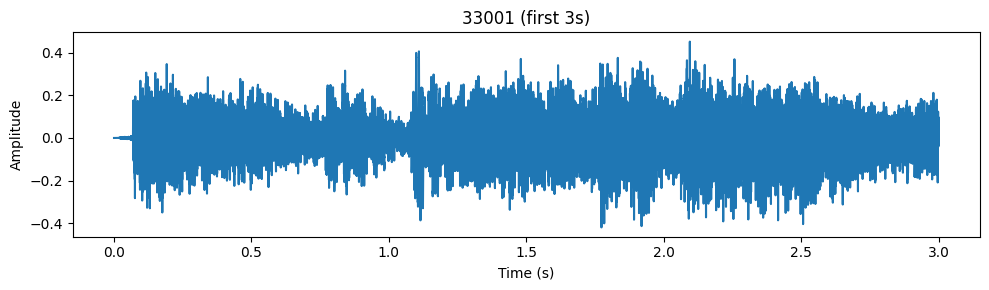

TID: 17366 | #tags: 2 | tags example: ['guitar', 'country']


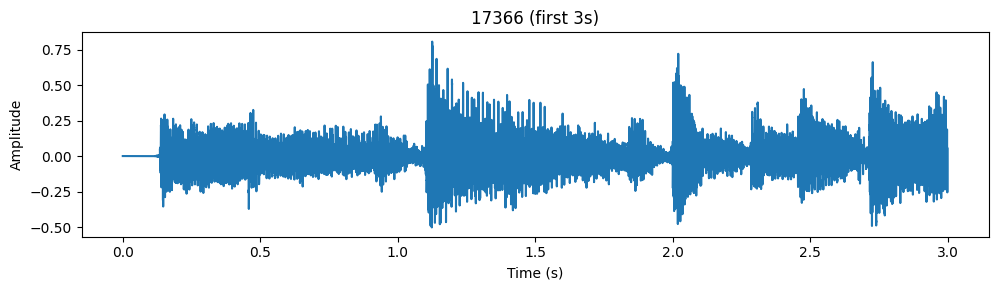

TID: 2150 | #tags: 3 | tags example: ['techno', 'electronic', 'synth']


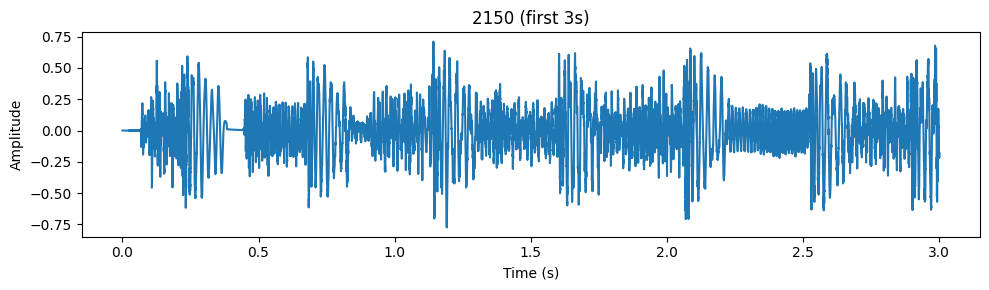

In [7]:
def load_track_audio(track_obj, target_sr=24000, mono=True):
    """
    Robust loader:
    1) try track_obj.audio (your local wrapper / mirdata)
    2) if it fails and track_obj has .path, try torchaudio.load(path)
    3) if torchaudio fails, try ffmpeg decode
    4) if everything fails, return short silence (will be padded later)
    """
    import subprocess, shutil

    def _ffmpeg_decode_to_float32_mono(path, sr_out):
        ff = shutil.which("ffmpeg")
        if ff is None:
            raise RuntimeError("ffmpeg not found in PATH (needed as fallback).")
        cmd = [
            ff, "-nostdin", "-v", "error",
            "-i", str(path),
            "-ac", "1",
            "-ar", str(int(sr_out)),
            "-f", "f32le",
            "pipe:1",
        ]
        raw = subprocess.check_output(cmd, stderr=subprocess.STDOUT)
        y = np.frombuffer(raw, dtype=np.float32)
        if y.size == 0:
            raise RuntimeError(f"ffmpeg decoded empty audio: {path}")
        return torch.from_numpy(y), int(sr_out)

    # ---- 1) try the standard route (works for good files)
    try:
        wav, sr = track_obj.audio
        wav = torch.tensor(wav).float()
        if wav.ndim > 1 and mono:
            wav = wav.mean(dim=0)
        if sr != target_sr:
            wav = torchaudio.functional.resample(wav, sr, target_sr)
            sr = target_sr
        return wav, sr

    except Exception as e1:
        # ---- 2) if local track provides a path, try direct loading
        path = getattr(track_obj, "path", None)

        # print only a few warnings to avoid spam
        if "BAD_AUDIO_COUNT" not in globals():
            globals()["BAD_AUDIO_COUNT"] = 0
        if globals()["BAD_AUDIO_COUNT"] < 5:
            print(f"[warn] audio load failed via track_obj.audio: {repr(e1)}")
            if path is not None:
                print(f"[warn] trying fallbacks for: {path}")
        globals()["BAD_AUDIO_COUNT"] += 1

        if path is not None:
            # ---- 2a) torchaudio.load(path)
            try:
                w, sr = torchaudio.load(str(path))
                if w.ndim == 2 and mono:
                    w = w.mean(dim=0)
                else:
                    w = w.squeeze(0)
                w = w.float()
                if sr != target_sr:
                    w = torchaudio.functional.resample(w, sr, target_sr)
                    sr = target_sr
                return w, sr
            except Exception:
                pass

            # ---- 2b) ffmpeg fallback (often works when torchaudio fails on MP3s)
            try:
                w, sr = _ffmpeg_decode_to_float32_mono(path, target_sr)
                if w.ndim > 1 and mono:
                    w = w.mean(dim=0)
                return w.float(), sr
            except Exception:
                pass

        # ---- 3) hard fallback: short silence (dataset will pad to the needed length)
        sr = int(target_sr)
        w = torch.zeros(int(sr * 1.0), dtype=torch.float32)  # 1s silence
        return w, sr

def plot_waveform(wav, sr, title="waveform", max_s=3.0):
    wav = wav.detach().cpu()
    n = min(int(sr * max_s), wav.numel())
    x = np.arange(n) / sr
    plt.figure(figsize=(10, 3))
    plt.plot(x, wav[:n].numpy())
    plt.title(title)
    plt.xlabel("Time (s)")
    plt.ylabel("Amplitude")
    plt.tight_layout()
    plt.show()

# pick a few samples
for tid in random.sample(train_ids, k=min(3, len(train_ids))):
    t = tracks[tid]
    tags = list(getattr(t, "tags", []) or [])
    wav, sr = load_track_audio(t, target_sr=24000)
    print("TID:", tid, "| #tags:", len(tags), "| tags example:", tags[:10])
    plot_waveform(wav, sr, title=f"{tid} (first 3s)")
    display(Audio(wav[:sr*3].detach().cpu().numpy(), rate=sr))

# resource sample
resource_sample()

# <h4 style="text-align: left; font-weight: bold;">DATASET DEFINITIONS</h4>

MTAT is multi-label: each track has a list of tags.  
We convert tag lists to multi-hot vectors using MultiLabelBinarizer

In [8]:
# ---- Safety: if tracks/train_ids are not defined (cell order issues), build local MTAT here.
if "tracks" not in globals() or "train_ids" not in globals() or "val_ids" not in globals() or "test_ids" not in globals():
    import csv
    from dataclasses import dataclass

    TOP_K_TAGS = 50

    def _has_mtat_layout(root: Path) -> bool:
        root = Path(root)
        return (
            (root / "annotations_final.csv").is_file()
            and (root / "clip_info_final.csv").is_file()
            and ((root / "audio").is_dir() or (root / "mp3").is_dir())
        )

    def _read_csv_dicts(path: Path):
        path = Path(path)
        with open(path, "r", encoding="utf-8", newline="") as f:
            first = f.readline()
        delim = "\t" if ("\t" in first and "," not in first) else ","
        with open(path, "r", encoding="utf-8", newline="") as f:
            reader = csv.DictReader(f, delimiter=delim)
            return list(reader)

    def find_datalabs_root():
        # Prefer env vars (lets you force the location)
        env_root = os.environ.get("MTAT_ROOT") or os.environ.get("MTAT_DATA_HOME")
        anchors = [Path.cwd()]
        if env_root:
            anchors.insert(0, Path(env_root))

        # Search upward (parallel folders style)
        for a in anchors:
            a = Path(a).expanduser().resolve()
            for p in [a] + list(a.parents):
                candidates = [
                    p / "data" / "datalabs",
                    p / "datalabs",
                    p / "data" / "mtat",
                    p / "mtat",
                    p,  # sometimes the root is directly here
                ]
                for cand in candidates:
                    if _has_mtat_layout(cand):
                        return cand

        raise FileNotFoundError(
            "MTAT not found. Expected a folder containing:\n"
            "  annotations_final.csv\n"
            "  clip_info_final.csv\n"
            "  audio/ (or mp3/)\n"
            "Tip: set env MTAT_ROOT or MTAT_DATA_HOME to the MTAT root folder."
        )

    def resolve_audio_root(base: Path) -> Path:
        base = Path(base)
        candidates = [
            base / "audio",
            base / "mp3",
            base.parent / "audio",
            base.parent / "mp3",
        ]
        for c in candidates:
            if c.exists() and c.is_dir():
                return c
        raise FileNotFoundError("audio folder not found near MTAT root")

    def normalize_mp3_rel(mp3_path: str) -> str:
        s = str(mp3_path).strip()
        if s.startswith("audio/"):
            s = s[len("audio/"):]
        if s.startswith("./"):
            s = s[2:]
        return s

    # ---- Locate MTAT root (Lab 8 style)
    base = find_datalabs_root()
    ann_path = base / "annotations_final.csv"
    info_path = base / "clip_info_final.csv"
    audio_root = resolve_audio_root(base)

    print("[fallback] MTAT root:", base)
    print("[fallback] annotations:", ann_path)
    print("[fallback] clip_info:", info_path)
    print("[fallback] audio_root:", audio_root)

    # ---- Read CSVs
    ann_rows = _read_csv_dicts(ann_path)
    info_rows = _read_csv_dicts(info_path)

    if len(ann_rows) == 0 or len(info_rows) == 0:
        raise ValueError("annotations_final.csv or clip_info_final.csv is empty/unreadable.")

    # ---- Identify columns
    if "clip_id" not in ann_rows[0] or "clip_id" not in info_rows[0]:
        raise ValueError("Expected column 'clip_id' in both annotations_final.csv and clip_info_final.csv")

    # Clip info must contain mp3_path
    if "mp3_path" not in info_rows[0]:
        print("clip_info columns:", list(info_rows[0].keys()))
        raise ValueError("Expected column 'mp3_path' in clip_info_final.csv")

    # Tag columns = all annotation columns except clip_id
    tag_cols_all = [c for c in ann_rows[0].keys() if c != "clip_id"]

    def to01(x):
        try:
            return int(float(str(x).strip()))
        except Exception:
            return 0

    # Build clip_id -> mp3_rel
    clip_to_mp3 = {}
    for r in info_rows:
        cid = str(r["clip_id"]).strip()
        clip_to_mp3[cid] = normalize_mp3_rel(r["mp3_path"])

    # Build clip_id -> full tag vector (all tags)
    clip_to_y = {}
    for r in ann_rows:
        cid = str(r["clip_id"]).strip()
        y = [to01(r.get(c, 0)) for c in tag_cols_all]
        clip_to_y[cid] = y

    # Keep only clips that have both audio path and annotation
    valid = []
    for cid, mp3_rel in clip_to_mp3.items():
        if cid not in clip_to_y:
            continue
        fp = audio_root / mp3_rel
        if fp.is_file():
            valid.append(cid)

    if len(valid) == 0:
        raise ValueError("No valid clips found (mp3 files missing). Check audio_root and mp3_path normalization.")

    # Select TOP_K_TAGS by frequency on valid clips
    Y_full = np.asarray([clip_to_y[cid] for cid in valid], dtype=np.int32)  # [N, C_all]
    freq = Y_full.sum(axis=0)
    top_idx = np.argsort(freq)[::-1][:TOP_K_TAGS]
    tag_cols_top = [tag_cols_all[i] for i in top_idx]

    @dataclass
    class LocalMTATTrack:
        path: Path
        tags: list

        @property
        def audio(self):
            # rely on your existing load_track_audio() (it does resample + mono)
            # so here return a numpy waveform + sr using torchaudio
            wav, sr = torchaudio.load(str(self.path))
            if wav.ndim == 2 and wav.shape[0] > 1:
                wav = wav.mean(dim=0, keepdim=True)
            wav = wav.squeeze(0).cpu().numpy()
            return wav, sr

    # Build tracks dict: key=clip_id, value=track object with .audio + .tags
    tracks = {}
    for cid in valid:
        mp3_rel = clip_to_mp3[cid]
        fp = audio_root / mp3_rel
        y = np.asarray(clip_to_y[cid], dtype=np.int32)[top_idx]
        tags = [t for t, v in zip(tag_cols_top, y) if v == 1]
        tracks[cid] = LocalMTATTrack(path=fp, tags=tags)

    track_ids = list(tracks.keys())
    print("[fallback] Total valid tracks:", len(track_ids))
    print("[fallback] Using top tags:", tag_cols_top[:10], "...")

    # Splits
    seed_everything(42)
    random.shuffle(track_ids)

    n = len(track_ids)
    train_ids = track_ids[: int(0.8 * n)]
    val_ids   = track_ids[int(0.8 * n): int(0.9 * n)]
    test_ids  = track_ids[int(0.9 * n):]

    print("[fallback] splits:", len(train_ids), len(val_ids), len(test_ids))

# ---- Dataset definitions (same as before)
class MTATAudioDataset(Dataset):
    def __init__(self, tracks_dict, track_ids, device, sample_rate=24000, audio_duration=3, mlb=None):
        self.tracks = tracks_dict
        self.track_ids = track_ids
        self.device = device
        self.sample_rate = sample_rate
        self.audio_duration = audio_duration
        self.n_samples = int(sample_rate * audio_duration)

        tag_lists = []
        for tid in self.track_ids:
            tags = list(getattr(self.tracks[tid], "tags", []) or [])
            tag_lists.append(tags)

        if mlb is None:
            self.mlb = MultiLabelBinarizer()
            self.Y = self.mlb.fit_transform(tag_lists).astype(np.float32)
        else:
            self.mlb = mlb
            self.Y = self.mlb.transform(tag_lists).astype(np.float32)

    def __len__(self):
        return len(self.track_ids)

    def __getitem__(self, idx):
        tid = self.track_ids[idx]
        t = self.tracks[tid]

        wav, sr = load_track_audio(t, target_sr=self.sample_rate, mono=True)

        if wav.numel() < self.n_samples:
            wav = F.pad(wav, (0, self.n_samples - wav.numel()))
            start = 0
        else:
            start = random.randint(0, wav.numel() - self.n_samples)

        x = wav[start:start + self.n_samples]
        y = torch.tensor(self.Y[idx]).float()

        return {"audio": x.to(self.device), "labels": y.to(self.device), "tid": tid}

# Create train with mlb fit val/test reuse the same mlb
train_audio = MTATAudioDataset(tracks, train_ids, device=device, sample_rate=24000, audio_duration=3, mlb=None)
val_audio   = MTATAudioDataset(tracks, val_ids, device=device, sample_rate=24000, audio_duration=3, mlb=train_audio.mlb)
test_audio  = MTATAudioDataset(tracks, test_ids, device=device, sample_rate=24000, audio_duration=3, mlb=train_audio.mlb)

n_classes = len(train_audio.mlb.classes_)
print("n_classes:", n_classes)
print("Example classes:", train_audio.mlb.classes_[:20])

resource_sample()

n_classes: 50
Example classes: ['ambient' 'beat' 'beats' 'cello' 'choir' 'choral' 'classic' 'classical'
 'country' 'dance' 'drums' 'electronic' 'fast' 'female' 'female vocal'
 'female voice' 'flute' 'guitar' 'harp' 'harpsichord']



# <h3 style="text-align: left; font-weight: bold;">EMBEDDING EXTRACTION</h3>

We extract embeddings using a pretrained representation model (OMAR-RQ) and cache them to disk:
* If cached embeddings exist, we load them instantly.
* Otherwise we compute embeddings in batches and save them.

This makes the notebook efficient and repeatable.

In [10]:
def get_cache_paths(split_name: str, layers: list):
    layers_tag = "_".join(map(str, layers))
    emb_path = cache_dir / f"emb_{split_name}_layers{layers_tag}.pt"
    y_path   = cache_dir / f"y_{split_name}_layers{layers_tag}.pt"
    tid_path = cache_dir / f"tid_{split_name}_layers{layers_tag}.json"
    return emb_path, y_path, tid_path

def _to_2d_embedding(emb: torch.Tensor) -> torch.Tensor:
    """
     embeddings always (B, D) no matter what omar_rq returns.

    Common cases:
      - (B, T, D) theh mean over T => (B, D)
      - (B, D, T) then mean over T => (B, D)
      - (B, D)   then keep
      - (B, ..., D) then global mean over all non-batch dims except the last
    """
    if not isinstance(emb, torch.Tensor):
        raise TypeError(f"Expected torch.Tensor, got {type(emb)}")

    if emb.ndim == 2:
        return emb

    if emb.ndim == 3:
     
        if emb.shape[1] <= emb.shape[2]:
            # likely (B, T, D)
            return emb.mean(dim=1)
        else:
            # likely (B, D, T)
            return emb.mean(dim=2)

    # Fallback: pool everything except batch and last dim
    # e.g. (B, C, T, D) -> mean over (C,T) => (B, D)
    dims_to_mean = list(range(1, emb.ndim - 1))
    if len(dims_to_mean) > 0:
        emb = emb.mean(dim=dims_to_mean)
    # Now should be (B, D)
    if emb.ndim != 2:
        emb = emb.view(emb.shape[0], -1)
    return emb

@torch.no_grad()
def compute_or_load_embeddings(
    split_name,
    audio_dataset,
    model_id="mtg-upf/clap_omarrq_mp_small_music",
    layers=[6],
    batch_size=32
):
    emb_path, y_path, tid_path = get_cache_paths(split_name, layers)

    if emb_path.exists() and y_path.exists() and tid_path.exists():
        print(f"[cache] Loading {split_name} embeddings from disk...")
        X = torch.load(emb_path, map_location="cpu")
        Y = torch.load(y_path, map_location="cpu")
        tids = json.loads(tid_path.read_text(encoding="utf-8"))
        return X, Y, tids

    print(f"[compute] Extracting {split_name} embeddings...")
    rep = get_model(model_id=model_id, device=device)
    rep.eval()

    loader = DataLoader(audio_dataset, batch_size=batch_size, shuffle=False)

    X_list, Y_list, T_list = [], [], []
    target_D = None  # will lock embedding dim after first batch

    for batch in tqdm(loader, desc=f"Embeddings {split_name}"):
        audio = batch["audio"]
        y = batch["labels"].detach().cpu()
        tids = list(batch["tid"])

        emb = rep.extract_embeddings(audio.float(), layers=layers)

        # omar_rq may return list/tuple depending on version
        if isinstance(emb, (list, tuple)):
            emb = emb[-1]

        emb = _to_2d_embedding(emb).detach().cpu()  # (B, D) guaranteed

        # lock D to avoid later cat() mismatches
        if target_D is None:
            target_D = emb.shape[1]
        else:
            if emb.shape[1] != target_D:
                # last resort: fix by trunc/pad (should be rare after correct pooling)
                if emb.shape[1] > target_D:
                    emb = emb[:, :target_D]
                else:
                    pad = target_D - emb.shape[1]
                    emb = torch.cat([emb, torch.zeros((emb.shape[0], pad), dtype=emb.dtype)], dim=1)

        X_list.append(emb)
        Y_list.append(y)
        T_list.extend(tids)

        if random.random() < 0.05:
            resource_sample()

    X = torch.cat(X_list, dim=0)
    Y = torch.cat(Y_list, dim=0)

    torch.save(X, emb_path)
    torch.save(Y, y_path)
    tid_path.write_text(json.dumps(T_list, ensure_ascii=False, indent=2), encoding="utf-8")

    print(f"[saved] {split_name}: X={tuple(X.shape)} Y={tuple(Y.shape)}")
    return X, Y, T_list

layers = [6]
X_train, Y_train, tids_train = compute_or_load_embeddings("train", train_audio, layers=layers, batch_size=32)
X_val,   Y_val,   tids_val   = compute_or_load_embeddings("val",   val_audio,   layers=layers, batch_size=32)
X_test,  Y_test,  tids_test  = compute_or_load_embeddings("test",  test_audio,  layers=layers, batch_size=32)

print("Train:", X_train.shape, Y_train.shape)
print("Val:  ", X_val.shape, Y_val.shape)
print("Test: ", X_test.shape, Y_test.shape)

resource_sample()

[compute] Extracting train embeddings...
OMAR-RQ: 396 weights loaded for `net`
OMAR-RQ: 2 weights loaded for `embedding_layer`


Embeddings train:   0%|          | 0/647 [00:00<?, ?it/s]

[warn] audio load failed via track_obj.audio: RuntimeError('Failed to create AudioDecoder for /Users/meco/MBP Files/Gits/ml-for-sound-and-music/datalabs/audio/e/solace-balance-04-djinn-146-175.mp3: Could not open input file: /Users/meco/MBP Files/Gits/ml-for-sound-and-music/datalabs/audio/e/solace-balance-04-djinn-146-175.mp3 Invalid data found when processing input')
[warn] trying fallbacks for: /Users/meco/MBP Files/Gits/ml-for-sound-and-music/datalabs/audio/e/solace-balance-04-djinn-146-175.mp3
[warn] audio load failed via track_obj.audio: RuntimeError('Failed to create AudioDecoder for /Users/meco/MBP Files/Gits/ml-for-sound-and-music/datalabs/audio/6/norine_braun-now_and_zen-08-gently-117-146.mp3: Could not open input file: /Users/meco/MBP Files/Gits/ml-for-sound-and-music/datalabs/audio/6/norine_braun-now_and_zen-08-gently-117-146.mp3 Invalid data found when processing input')
[warn] trying fallbacks for: /Users/meco/MBP Files/Gits/ml-for-sound-and-music/datalabs/audio/6/norine_b

Embeddings val:   0%|          | 0/81 [00:00<?, ?it/s]

[warn] audio load failed via track_obj.audio: RuntimeError('Failed to create AudioDecoder for /Users/meco/MBP Files/Gits/ml-for-sound-and-music/datalabs/audio/8/jacob_heringman-josquin_des_prez_lute_settings-19-gintzler__pater_noster-204-233.mp3: Could not open input file: /Users/meco/MBP Files/Gits/ml-for-sound-and-music/datalabs/audio/8/jacob_heringman-josquin_des_prez_lute_settings-19-gintzler__pater_noster-204-233.mp3 Invalid data found when processing input')
[warn] trying fallbacks for: /Users/meco/MBP Files/Gits/ml-for-sound-and-music/datalabs/audio/8/jacob_heringman-josquin_des_prez_lute_settings-19-gintzler__pater_noster-204-233.mp3
[saved] val: X=(81, 512) Y=(2586, 50)
[compute] Extracting test embeddings...
OMAR-RQ: 396 weights loaded for `net`
OMAR-RQ: 2 weights loaded for `embedding_layer`


Embeddings test:   0%|          | 0/81 [00:00<?, ?it/s]

[saved] test: X=(81, 512) Y=(2587, 50)
Train: torch.Size([647, 512]) torch.Size([20690, 50])
Val:   torch.Size([81, 512]) torch.Size([2586, 50])
Test:  torch.Size([81, 512]) torch.Size([2587, 50])


# <h3 style="text-align: left; font-weight: bold;">MLP CLASSIFIER</h3>

We train an MLP on top of cached embeddings.  
Because MTAT is multi-label, we use:
* BCEWithLogitsLoss (stable sigmoid + BCE combined)
* sigmoid at inference time

In [12]:
class EmbeddingDataset(Dataset):
    def __init__(self, X, Y):
        self.X = X.float()
        self.Y = Y.float()

    def __len__(self):
        return self.X.shape[0]

    def __getitem__(self, idx):
        return {"embeddings": self.X[idx], "labels": self.Y[idx]}

train_ds = EmbeddingDataset(X_train, Y_train)
val_ds   = EmbeddingDataset(X_val,   Y_val)
test_ds  = EmbeddingDataset(X_test,  Y_test)

train_loader = DataLoader(train_ds, batch_size=128, shuffle=True)
val_loader   = DataLoader(val_ds,   batch_size=256, shuffle=False)
test_loader  = DataLoader(test_ds,  batch_size=256, shuffle=False)

class MLP(nn.Module):
    def __init__(self, input_size, hidden=256, output_size=50, dropout=0.2):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_size, hidden),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden, output_size),
        )

    def forward(self, x):
        return self.net(x)

input_dim = X_train.shape[1]
model = MLP(input_size=input_dim, hidden=256, output_size=n_classes, dropout=0.2).to(device)

loss_fn = nn.BCEWithLogitsLoss()
opt = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-5)

print(model)
print("Trainable params:", sum(p.numel() for p in model.parameters() if p.requires_grad))

resource_sample()

MLP(
  (net): Sequential(
    (0): Linear(in_features=512, out_features=256, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=256, out_features=50, bias=True)
  )
)
Trainable params: 144178


In [13]:
# checkpoints: save best model + resume support
def save_checkpoint(path, model, optimizer, epoch, history, extra=None):
    payload = {
        "epoch": epoch,
        "model_state": model.state_dict(),
        "optim_state": optimizer.state_dict(),
        "history": history,
        "extra": extra or {},
    }
    torch.save(payload, path)

def load_checkpoint(path, model, optimizer=None):
    ckpt = torch.load(path, map_location="cpu")
    model.load_state_dict(ckpt["model_state"])
    if optimizer is not None and "optim_state" in ckpt:
        optimizer.load_state_dict(ckpt["optim_state"])
    return ckpt

best_model_path = cache_dir / "best_model.pt"
last_ckpt_path  = cache_dir / "last_checkpoint.pt"

# <h3 style="text-align: left; font-weight: bold;">TRAINLOOP</h3>

We train for a small number of epochs and track:
* train/val loss
* (optional) validation ROC-AUC / PR-AUC every few epochs (kept efficient)

ASlso:
* Resume from last checkpoint if available
* Save best_model.pt based on val PR AUC (micro!)

In [14]:


@torch.no_grad()
def predict_probs(model, loader):
    model.eval()
    ys, ps = [], []
    for batch in loader:
        x = batch["embeddings"].to(device)
        y = batch["labels"].cpu().numpy()
        logits = model(x)
        p = torch.sigmoid(logits).detach().cpu().numpy()
        ys.append(y)
        ps.append(p)
    return np.vstack(ys), np.vstack(ps)

def train_one_epoch(model, loader):
    model.train()
    total = 0.0
    for batch in loader:
        x = batch["embeddings"].to(device)
        y = batch["labels"].to(device)

        logits = model(x)
        loss = loss_fn(logits, y)

        opt.zero_grad()
        loss.backward()
        opt.step()

        total += float(loss.item())
    return total / max(1, len(loader))

@torch.no_grad()
def eval_loss(model, loader):
    model.eval()
    total = 0.0
    for batch in loader:
        x = batch["embeddings"].to(device)
        y = batch["labels"].to(device)
        logits = model(x)
        loss = loss_fn(logits, y)
        total += float(loss.item())
    return total / max(1, len(loader))

def safe_auc_pr(y_true, y_prob):
    out = {}
    try:
        out["roc_auc_macro"] = float(roc_auc_score(y_true, y_prob, average="macro"))
    except Exception:
        out["roc_auc_macro"] = None
    try:
        out["roc_auc_micro"] = float(roc_auc_score(y_true, y_prob, average="micro"))
    except Exception:
        out["roc_auc_micro"] = None
    try:
        out["pr_auc_macro"] = float(average_precision_score(y_true, y_prob, average="macro"))
    except Exception:
        out["pr_auc_macro"] = None
    try:
        out["pr_auc_micro"] = float(average_precision_score(y_true, y_prob, average="micro"))
    except Exception:
        out["pr_auc_micro"] = None
    return out

history = {"epoch": [], "train_loss": [], "val_loss": [], "val_roc_auc_macro": [], "val_roc_auc_micro": [], "val_pr_auc_macro": [], "val_pr_auc_micro": []}

best_val_pr_micro = -1.0
start_epoch = 1

# Resume (optional)
if last_ckpt_path.exists():
    print("[resume] Loading last checkpoint:", last_ckpt_path)
    ckpt = load_checkpoint(last_ckpt_path, model, opt)
    history = ckpt.get("history", history)
    start_epoch = ckpt.get("epoch", 0) + 1
    best_val_pr_micro = ckpt.get("extra", {}).get("best_val_pr_micro", best_val_pr_micro)

n_epochs = 2
for epoch in range(start_epoch, n_epochs + 1):
    tr = train_one_epoch(model, train_loader)
    va = eval_loss(model, val_loader)

    metrics = {"roc_auc_macro": None, "roc_auc_micro": None, "pr_auc_macro": None, "pr_auc_micro": None}
    if epoch % 3 == 0 or epoch == n_epochs:
        Yt, Yp = predict_probs(model, val_loader)
        metrics = safe_auc_pr(Yt, Yp)

    history["epoch"].append(epoch)
    history["train_loss"].append(tr)
    history["val_loss"].append(va)
    history["val_roc_auc_macro"].append(metrics["roc_auc_macro"])
    history["val_roc_auc_micro"].append(metrics["roc_auc_micro"])
    history["val_pr_auc_macro"].append(metrics["pr_auc_macro"])
    history["val_pr_auc_micro"].append(metrics["pr_auc_micro"])

    val_pr_micro = metrics["pr_auc_micro"]
    print(f"epoch {epoch:02d} | train_loss={tr:.4f} | val_loss={va:.4f} | val_pr_micro={val_pr_micro}")

    # Save best
    if val_pr_micro is not None and val_pr_micro > best_val_pr_micro:
        best_val_pr_micro = val_pr_micro
        print(f"[best] New best val PR-AUC micro: {best_val_pr_micro:.4f} -> saving best_model.pt")
        torch.save(model.state_dict(), best_model_path)

    # Save last checkpoint
    save_checkpoint(
        last_ckpt_path,
        model=model,
        optimizer=opt,
        epoch=epoch,
        history=history,
        extra={"best_val_pr_micro": best_val_pr_micro},
    )

    resource_sample()

epoch 01 | train_loss=0.6132 | val_loss=0.4786 | val_pr_micro=None
epoch 02 | train_loss=0.3743 | val_loss=0.2619 | val_pr_micro=0.05904895580235478
[best] New best val PR-AUC micro: 0.0590 -> saving best_model.pt


/Users/meco/MBP Files/Gits/upfs-virtualenv/lib/python3.11/site-packages/sklearn/metrics/_ranking.py:442: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
/Users/meco/MBP Files/Gits/upfs-virtualenv/lib/python3.11/site-packages/sklearn/metrics/_ranking.py:442: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
/Users/meco/MBP Files/Gits/upfs-virtualenv/lib/python3.11/site-packages/sklearn/metrics/_ranking.py:1131: UserWarning: No positive class found in y_true, recall is set to one for all thresholds.
  warnings.warn(
/Users/meco/MBP Files/Gits/upfs-virtualenv/lib/python3.11/site-packages/sklearn/metrics/_ranking.py:1131: UserWarning: No positive class found in y_true, recall is set to one for all thresholds.
  warnings.warn(
/Users/meco/MBP Files/Gits/upfs-virtualenv/lib/python3.11/site-packages/sklearn/metrics/_ranking.py:1131: UserWarning: No po

# <h3 style="text-align: left; font-weight: bold;">FINAL EVALUATION</h3>


We report:
* ROC-AUC (macro, micro)
* PR-AUC (macro, micro)

We also keep results in a dictionary for easy reuse in the report.

In [15]:
Yt_test, Yp_test = predict_probs(model, test_loader)
test_metrics = safe_auc_pr(Yt_test, Yp_test)

print("TEST METRICS")
for k, v in test_metrics.items():
    print(f"{k}: {v}")

results = {
    "device": str(device),
    "platform": platform.platform(),
    "torch_version": torch.__version__,
    "layers": layers,
    "input_dim": int(input_dim),
    "n_classes": int(n_classes),
    "epochs": int(n_epochs),
    "final_test_metrics": test_metrics,
    "history": history,
}

results_path = cache_dir / "results_lab9_mtat_transfer.json"
results_path.write_text(json.dumps(results, ensure_ascii=False, indent=2), encoding="utf-8")
print("Saved:", results_path)

resource_sample()

TEST METRICS
roc_auc_macro: nan
roc_auc_micro: 0.5069193574008954
pr_auc_macro: 0.10686352805351071
pr_auc_micro: 0.05958009059931772
Saved: /Users/meco/MBP Files/Gits/ml-for-sound-and-music/lab09/cache_mtat_transfer/results_lab9_mtat_transfer.json


/Users/meco/MBP Files/Gits/upfs-virtualenv/lib/python3.11/site-packages/sklearn/metrics/_ranking.py:442: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
/Users/meco/MBP Files/Gits/upfs-virtualenv/lib/python3.11/site-packages/sklearn/metrics/_ranking.py:442: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
/Users/meco/MBP Files/Gits/upfs-virtualenv/lib/python3.11/site-packages/sklearn/metrics/_ranking.py:442: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
/Users/meco/MBP Files/Gits/upfs-virtualenv/lib/python3.11/site-packages/sklearn/metrics/_ranking.py:1131: UserWarning: No positive class found in y_true, recall is set to one for all thresholds.
  warnings.warn(
/Users/meco/MBP Files/Gits/upfs-virtualenv/lib/python3.11/site-packages/sklearn/metrics/_ranking.py:1131: User

# <h2 style="text-align: center; font-weight: bold;">PLOTS FOR THE REPORT</h2>


We plot:
* Train/val loss curve
* (If computed) validation ROC-AUC and PR-AUC curves

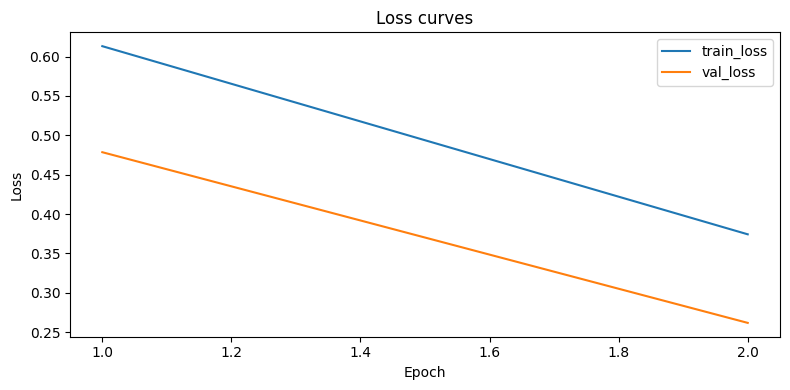

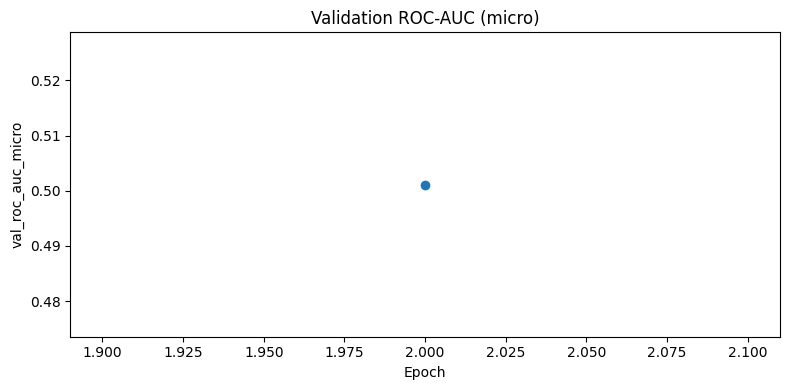

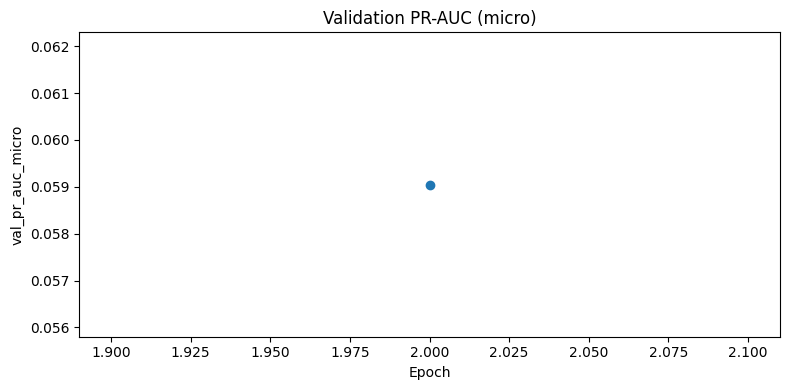

In [16]:
epochs = history["epoch"]

plt.figure(figsize=(8,4))
plt.plot(epochs, history["train_loss"], label="train_loss")
plt.plot(epochs, history["val_loss"], label="val_loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss curves")
plt.legend()
plt.tight_layout()
plt.show()

def plot_metric(metric_name, title):
    vals = history[metric_name]
    xs = [e for e, v in zip(epochs, vals) if v is not None]
    ys = [v for v in vals if v is not None]
    if len(xs) == 0:
        print(f"No values for {metric_name}")
        return
    plt.figure(figsize=(8,4))
    plt.plot(xs, ys, marker="o")
    plt.xlabel("Epoch")
    plt.ylabel(metric_name)
    plt.title(title)
    plt.tight_layout()
    plt.show()

plot_metric("val_roc_auc_micro", "Validation ROC-AUC (micro)")
plot_metric("val_pr_auc_micro", "Validation PR-AUC (micro)")

resource_sample()

# <h3 style="text-align: left; font-weight: bold;">RESOURCES AND EMISSIONS SUMMARY </h3>

We stop the tracker and show:
* CO2 estimate (CodeCarbon)
* Peak RAM and peak CUDA memory (if applicable)
* A quick plot of CPU and RAM over time

Stopping emissions tracker...
Saved: /Users/meco/MBP Files/Gits/ml-for-sound-and-music/lab09/cache_mtat_transfer/resource_emissions_summary.json
{'emissions_kg_co2eq': 0.002577504541231977, 'peak_ram_gb': 25.92529296875, 'peak_cpu_percent': 48.6, 'peak_cuda_mem_alloc_gb': 0.0}


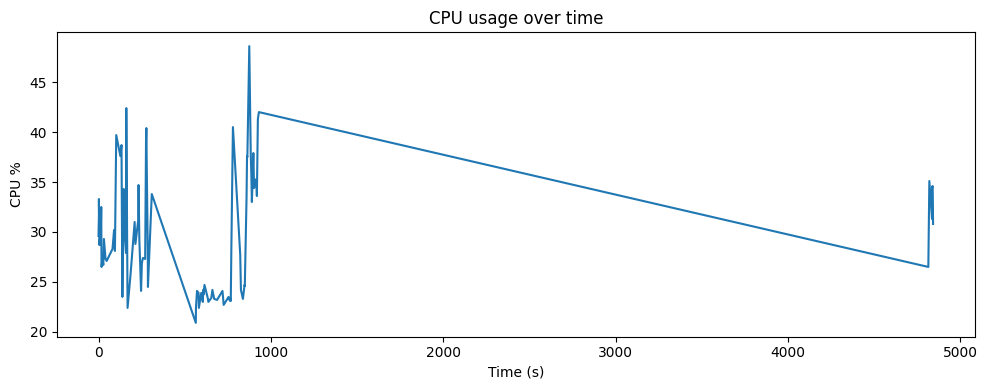

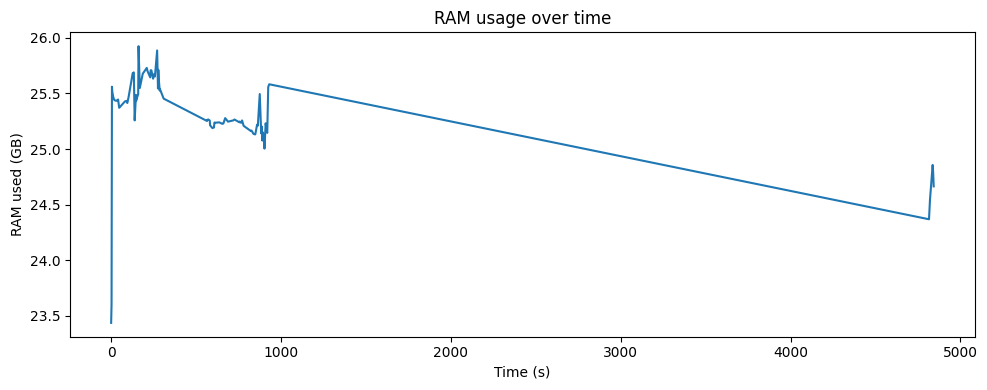

In [17]:
print("Stopping emissions tracker...")
emissions = emissions_tracker.stop()  # returns kgCO2eq (may be None depending on config)

# Summaries
peak_ram = max(resource_log.ram_used_gb) if resource_log.ram_used_gb else None
peak_cpu = max(resource_log.cpu_percent) if resource_log.cpu_percent else None
peak_cuda_alloc = max(resource_log.cuda_mem_alloc_gb) if resource_log.cuda_mem_alloc_gb else None

summary = {
    "emissions_kg_co2eq": emissions,
    "peak_ram_gb": peak_ram,
    "peak_cpu_percent": peak_cpu,
    "peak_cuda_mem_alloc_gb": peak_cuda_alloc,
}

summary_path = cache_dir / "resource_emissions_summary.json"
summary_path.write_text(json.dumps(summary, ensure_ascii=False, indent=2), encoding="utf-8")
print("Saved:", summary_path)
print(summary)

# Plots
ts = resource_log.timestamps_s

plt.figure(figsize=(10,4))
plt.plot(ts, resource_log.cpu_percent)
plt.xlabel("Time (s)")
plt.ylabel("CPU %")
plt.title("CPU usage over time")
plt.tight_layout()
plt.show()

plt.figure(figsize=(10,4))
plt.plot(ts, resource_log.ram_used_gb)
plt.xlabel("Time (s)")
plt.ylabel("RAM used (GB)")
plt.title("RAM usage over time")
plt.tight_layout()
plt.show()

if torch.cuda.is_available():
    plt.figure(figsize=(10,4))
    plt.plot(ts, resource_log.cuda_mem_alloc_gb, label="allocated")
    plt.plot(ts, resource_log.cuda_mem_reserved_gb, label="reserved")
    plt.xlabel("Time (s)")
    plt.ylabel("CUDA memory (GB)")
    plt.title("CUDA memory over time")
    plt.legend()
    plt.tight_layout()
    plt.show()

# <h2 style="text-align: center; font-weight: bold;">REPORT</h2>
